# Connectivity

In [85]:
import pandas as pd
import numpy as np
import json
import os
import pickle
import seaborn as sns
from scipy.stats import spearmanr
from scipy.signal import coherence
import matplotlib.pyplot as plt

from utils import OUT_PATH, GetInfo, ExcludSubj, FREQ_BAND, EVENT_ID

tfr_path = OUT_PATH+ '/Data_longWOBS'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)
print(f"Subject Nbr is {len(subj_included)}")

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_tfr=d['time_tfr']
     
coord, areas, elect_list, subj_list, regions = GetInfo(subj_included, data_path=tfr_path)

Subject Nbr is 30


In [86]:
events = ['old/correct', 'new/correct']
band = 'high_gamma'
pc='compo2'
switch_id = 68 # 0.75s
weight = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == @band & compo == @pc').drop(columns = ['Unnamed: 0', 'freq', 'compo']).values[0, :]
data_ch = pd.DataFrame()
data_ch['ch1'] = np.where(abs(weight) > abs(weight).mean() + abs(weight).std(), True, False)
data_ch['subj'] = subj_list
data_ch['ROIs'] = regions

trials ={ev:[] for ev in events}
for subj in np.unique(subj_list) :
    data_subj = data_ch.query('subj == @subj').reset_index()
    ch = data_subj.query("ch1 == True").index

    file = tfr_path + f'/{subj}_TFRtrials.p'
    with open(file, "rb") as f:
        tr = pickle.load(f)

    info_file = tfr_path + f'/{subj}_info.json'
    with open(info_file) as f:
         info = json.load(f)
         events_index = np.array([int(i) for i in info['event_id']])

    id_ch = np.array(ch)
    for ev in events : 
        id_ev = np.where(events_index == EVENT_ID[ev])[0]

        if len(id_ch) == 0 : 
            continue
        tr_band = tr[np.ix_(id_ev, id_ch,[FREQ_BAND.index(band)], range(tr.shape[-1]))]
        trials[ev].append(tr_band)


data = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data[ev].extend([tr[:,c, :] for c in range(tr.shape[1])])

In [92]:
# first time window : before switch
data_a = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_a[ev].extend([tr[:,c, 0,switch_id:120] for c in range(tr.shape[1])])

spear_a = np.zeros([len(data_a['old/correct']), len(data_a['old/correct'])])
for i,x in enumerate(data_a['old/correct']):
    for j,y in enumerate(data_a['old/correct']) :
        min_trial = np.min([x.shape[0], y.shape[0]])
        spear_a[i, j] = np.mean(spearmanr(x[:min_trial, :], y[:min_trial, :]).statistic) # for now spearman correlation between electrods but might do somthing more sophisticate
        

KeyboardInterrupt: 

In [ ]:
data_b = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_b[ev].extend([tr[:,c, 0,25:switch_id] for c in range(tr.shape[1])])

spear_b = np.zeros([len(data_b['old/correct']), len(data_a['old/correct'])])
for i,x in enumerate(data_b['old/correct']):
    for j,y in enumerate(data_b['old/correct']) :
        min_trial = np.min([x.shape[0], y.shape[0]])
        spear_b[i, j] = np.mean(spearmanr(x[:min_trial, :], y[:min_trial, :]).statistic) # for now spearman correlation between electrods but might do somthing more sophisticate
        


In [ ]:
rois = data_ch[data_ch['ch1'] == True]['ROIs'].values

for mi in [spear_a, spear_b] : 
    df_Mi = pd.DataFrame(mi, columns = rois)
    df_Mi['rois'] = rois
    df_Mi= df_Mi.set_index('rois')
    df_Mi = df_Mi.reset_index().groupby('rois').mean().T.reset_index().groupby('index').mean().T

    sns.heatmap(df_Mi, vmin= -9.5, vmax = -8.9)
    plt.show()

In [ ]:
# set the metric a link of the network 
import networkx as nx
Ga = nx.Graph()
Ga.add_node_from(rois)
for r1 in rois : 
    for r2 in rois :
        Ga.add_edge(r1, r2, weight=spear_a)


Gb = nx.Graph()
Gb.add_node_from(rois)
for r1 in rois : 
    for r2 in rois :
        Gb.add_edge(r1, r2, weight=spear_b)

centralitya = nx.degree_centrality(Ga)
centralityb = nx.degree_centrality(Gb)
bentralitya = nx.betweenness_centrality(Ga)
bentralityb = nx.betweenness_centrality(Gb)
clusteringa = nx.Clustering(Ga)
clusteringb = nx.Clustering(Gb)
global_efficiencya = nx.global_efficiency(Ga)
global_efficiencyb = nx.global_efficiency(Gb)
worldnesa = nx.sigma(Ga)
worldnesb = nx.sigma(Gb)


## With Mutual info -- don't work too small sample even lumping the Rois elect

In [75]:
from sklearn.neighbors import NearestNeighbors
from scipy.special import digamma

# k The number of nearest neighbors used to estimate local probability density around each sample point.
def kraskov_mi(x, y, k=5):
    xy = np.column_stack((x, y))
    n = len(x)

    nbrs = NearestNeighbors(n_neighbors=k+1, metric='chebyshev')
    nbrs.fit(xy)
    distances, _ = nbrs.kneighbors(xy)
    eps = distances[:, k]  

    nx = []
    ny = []

    for i in range(n):
        nx.append(np.sum(np.abs(x - x[i]) < eps[i]) - 1)
        ny.append(np.sum(np.abs(y - y[i]) < eps[i]) - 1)

    nx = np.array(nx)
    ny = np.array(ny)

    mi = digamma(k) + digamma(n) - np.mean(digamma(nx+1) + digamma(ny+1))
    return mi


In [76]:
# first time window : before switch
data_b = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_b[ev].extend([tr[:,c, 0,25:switch_id] for c in range(tr.shape[1])])


In [77]:
# concat all the electrods of the same area to use mi
data_b_r = {ev:{r: [] for r in regions} for ev in events}

for ev in events :
    min_ = []
    d_r = {r: [] for r in regions} 
    for r in np.unique(regions) :
        id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
        if len(id_) == 0 : 
            min_.append(0)
            continue
        for i in id_ : 
            d_r[r].append(data_b[ev][i])

        min_.append(np.min([len(d_r[r][i]) for i in range(len(d_r[r]))]))

    for ir, r in enumerate(np.unique(regions)) :
        id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
        l = [d_r[r][i][:min_[ir]] for i in range(len(d_r[r])) if min_[ir] != 0]
        if len(l) != 0 :
            data_b_r[ev][r] = np.vstack(l)

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/

In [82]:
# at Rois level
Mi_b = np.zeros([len(data_b_r['old/correct']), len(data_b_r['old/correct'])])

for k in [1, 2, 3, 4] :
    for i,items_x in enumerate(data_b_r['old/correct'].items()):
        xk, xv= items_x
        if len(xv) == 0 :
            continue

        for j,items_y in enumerate(data_b_r['old/correct'].items()) :
            yk, yv= items_y
            if len(yv) == 0 :
                continue
            min_trial = np.min([xv.shape[0], yv.shape[0]])
            
            Mi_b[i, j] = kraskov_mi(xv[:min_trial, :], yv[:min_trial, :], k=k)
    
    print(np.min(Mi_b), np.max(Mi_b))


-14.057431094112868 0.0
-13.123090717732214 0.0
-12.652577306626188 0.0
-12.339663171533523 0.0


In [62]:
# first time window : before switch
data_a = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_a[ev].extend([tr[:,c, 0,switch_id:120] for c in range(tr.shape[1])])

Mi_a = np.zeros([len(data_a['old/correct']), len(data_a['old/correct'])])
for i,x in enumerate(data_a['old/correct']):
    for j,y in enumerate(data_a['old/correct']) :
        min_trial = np.min([x.shape[0], y.shape[0]])
        Mi_a[i, j] = kraskov_mi(x[:min_trial, :], y[:min_trial, :], k=5)



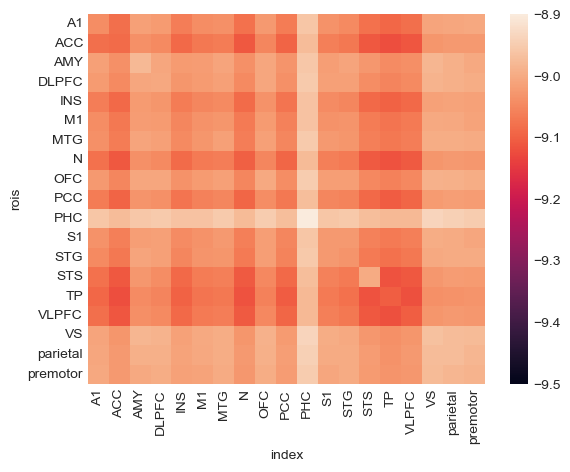

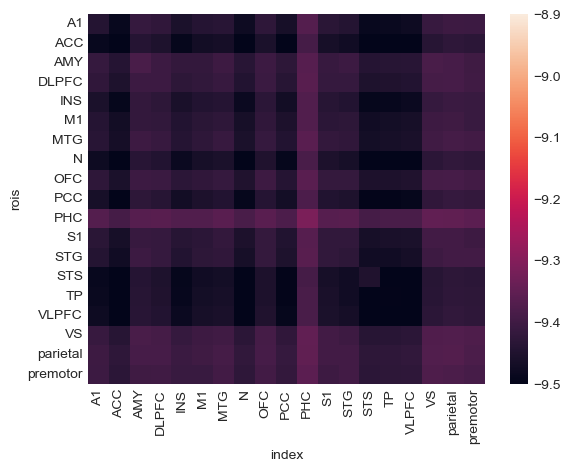

In [65]:
rois = data_ch[data_ch['ch1'] == True]['ROIs'].values

for mi in [Mi_b, Mi_a] : 
    df_Mi = pd.DataFrame(mi, columns = rois)
    df_Mi['rois'] = rois
    df_Mi= df_Mi.set_index('rois')
    df_Mi = df_Mi.reset_index().groupby('rois').mean().T.reset_index().groupby('index').mean().T

    sns.heatmap(df_Mi, vmin= -9.5, vmax = -8.9)
    plt.show()